In [1]:
from diffusers import StableDiffusionXLPipeline
import torch

In [2]:
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [3]:
pipe = pipe.to('mps')
pipe.unet = torch.compile(pipe.unet, mode="reduce-overhead", fullgraph=True)

In [4]:
prompt = """Photorealistic close-up portrait of an adorable quokka wearing round eyeglasses, a vivid red satin ribbon wrapped around its face beneath the eyes and tied into a neat bow at the side of its head, both the red ribbon and eyeglasses clearly visible, eyes unobstructed, cute friendly expression, detailed soft brown fur, centered composition, soft natural lighting, shallow depth of field, light bokeh, sharp focus, vibrant colors, high detail"""
negative_prompt = """human, person, man, beard, mech suit, armor, ribbon covering eyes, blindfold, gag, missing glasses, sunglasses, distorted glasses, extra glasses, deformed face, mutated, malformed, asymmetrical, duplicate animal, cropped, out of frame, cut off, blurry, grainy, out of focus, lowres, low detail, worst quality, low quality, overexposed, underexposed, grayscale, watermark, signature, text, username, logo, letters, digits, jpeg artifacts, cartoon, anime, illustration, cgi, render, blender"""


In [5]:
with torch.inference_mode():
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=50,
        guidance_scale=7.5
    )

image = result.images[0]


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (90 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['of field , light bokeh , sharp focus , vibrant colors , high detail']
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (90 > 77). Running this sequence through the model will result in indexing errors
The following part o

  0%|          | 0/50 [00:00<?, ?it/s]

/Users/hyeon/3_AI/.venv/lib/python3.12/site-packages/torch/_dynamo/variables/functions.py:2459: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function at 'activations.py:108'. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS=+dynamo for a DEBUG stack trace.

This call originates from:
  File "/Users/hyeon/3_AI/.venv/lib/python3.12/site-packages/diffusers/models/activations.py", line 108, in gelu
    if gate.device.type == "mps" and is_torch_version("<", "2.0.0"):

  torch._dynamo.utils.warn_once(msg)
/Users/hyeon/3_AI/.venv/lib/python3.12/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface

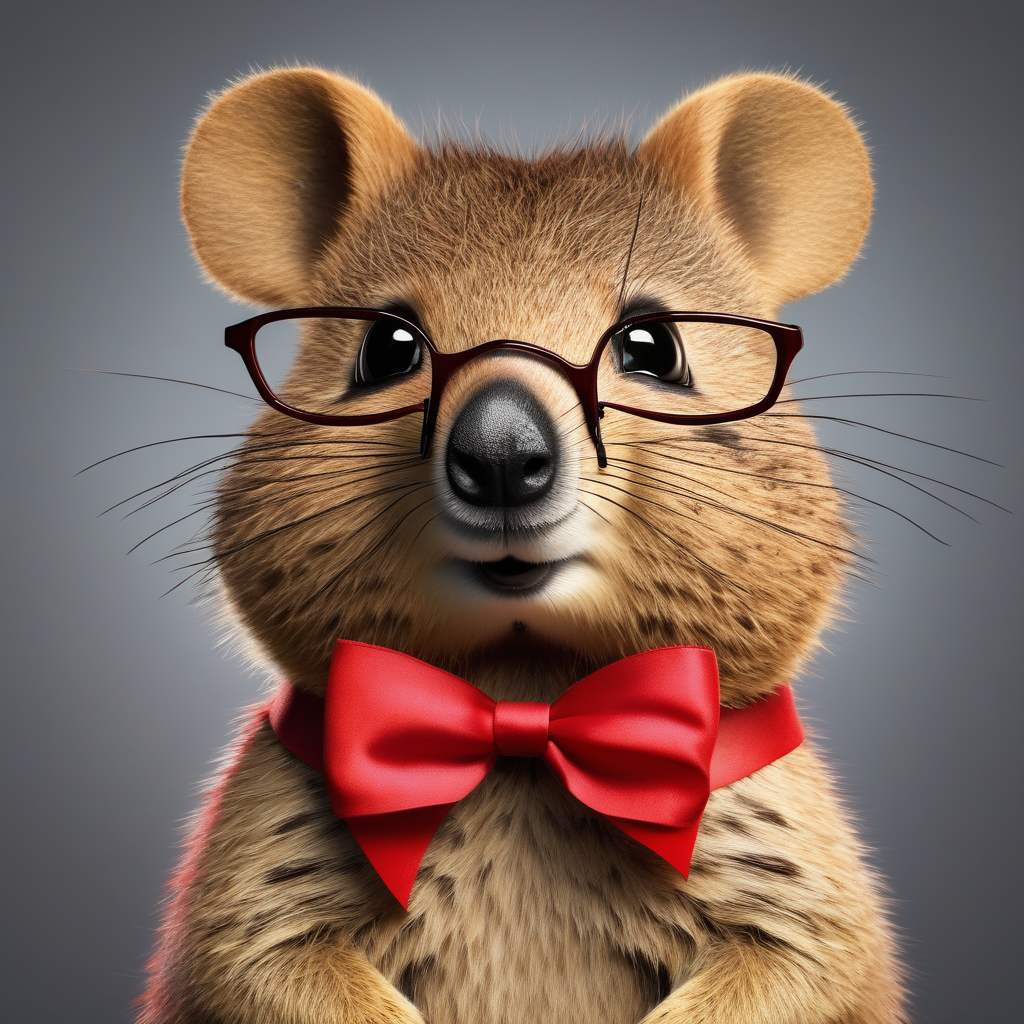

In [6]:
image

In [8]:
type(image)

PIL.Image.Image

In [7]:
image.save('./seung_un.jpg')